In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

In [2]:

df = pd.read_csv("diabetesprediction.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


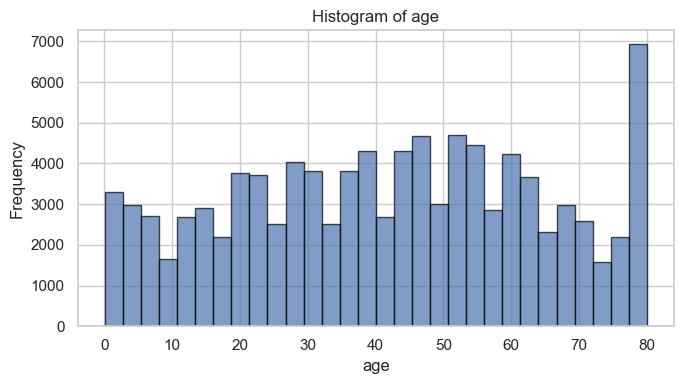

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


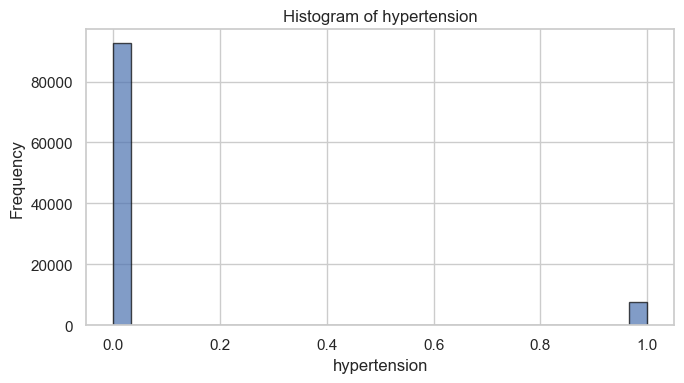

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


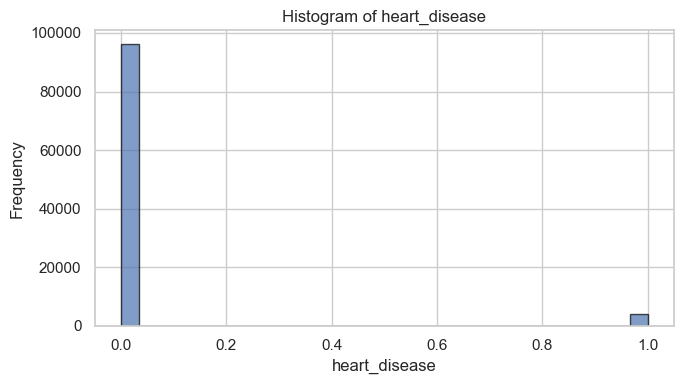

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


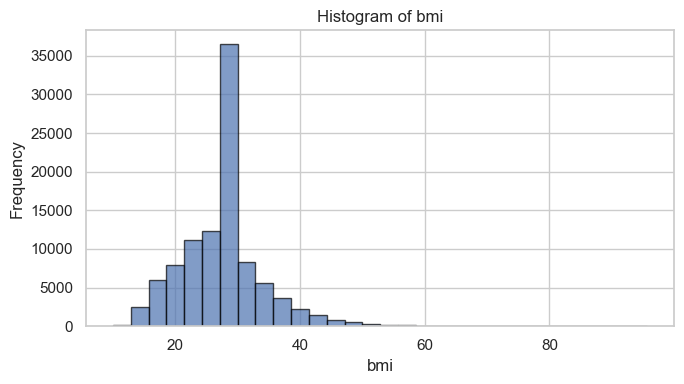

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


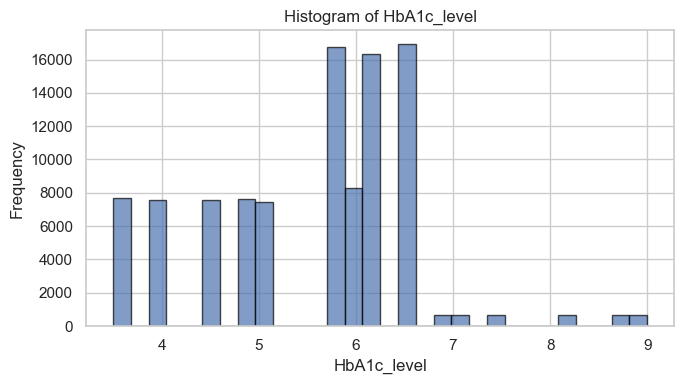

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


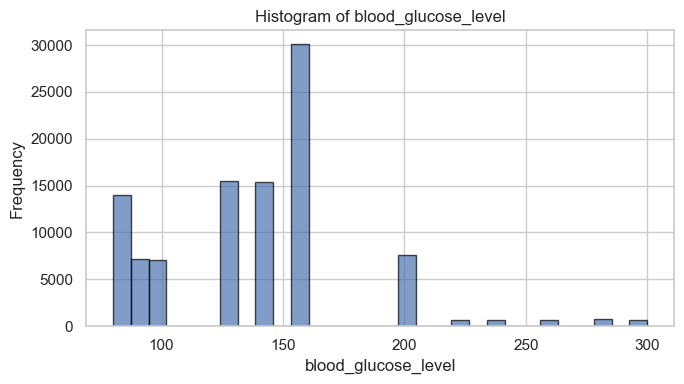

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


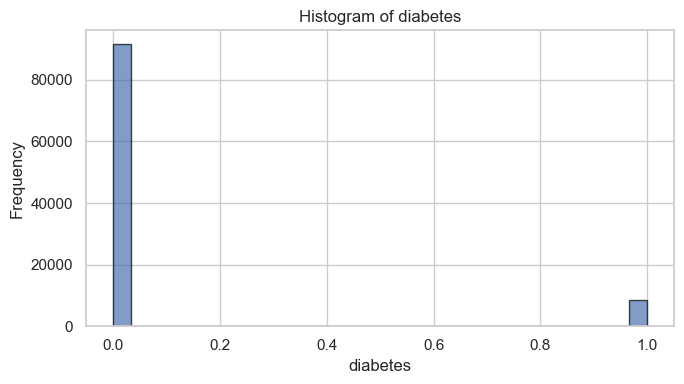

In [3]:
sns.set_theme(style="whitegrid")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30, edgecolor="black", alpha=0.7)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig( "diabetes_1.eps", format="eps", dpi=600, bbox_inches="tight" )
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


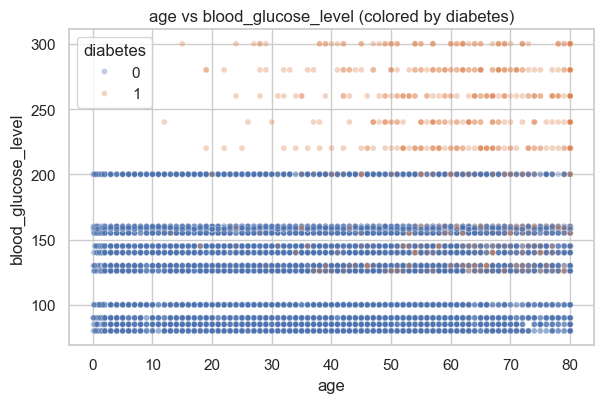

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


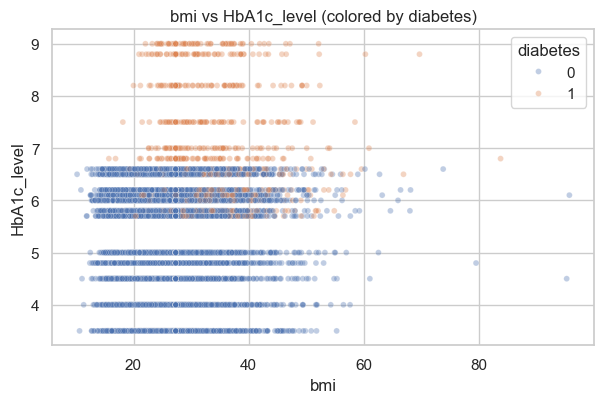

In [4]:
TARGET = "diabetes"
pairs = [("age", "blood_glucose_level"), ("bmi", "HbA1c_level")]
count=2
for a, b in pairs:
    if a in df.columns and b in df.columns:
        plt.figure(figsize=(6.2, 4.2))
        sns.scatterplot(data=df.sample(min(12000, len(df)), random_state=42),
                        x=a, y=b, hue=TARGET, alpha=0.35, s=18)
        plt.title(f"{a} vs {b} (colored by diabetes)")
        plt.tight_layout()
        plt.savefig( f"diabetes{count}.eps", format="eps", dpi=600, bbox_inches="tight" )
        count=count+1
        plt.show()

In [ ]:
sns.pairplot(df, hue="diabetes")
plt.savefig( f"diabetes{count}.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [ ]:
null_cols = df.columns[df.isnull().any()]
null_rows = df[df[null_cols].isnull().any(axis = 1)]
print("Rows with null values are: ")
print(null_rows)

In [ ]:
plt.figure(figsize=(6.2, 4.2))
sns.scatterplot(x = 'gender',y = 'age', data=df,hue = 'diabetes')
plt.title(f"gender vs age (colored by diabetes)")
plt.tight_layout()
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
X = df.drop(columns="diabetes")
y = df["diabetes"]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns
preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_processed = preprocessor.fit_transform(X)

cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_features])
chi_scores, p_values = chi2(X_processed, y)

chi_df = pd.DataFrame({
    "Feature": feature_names,
    "Chi2_Score": chi_scores,
    "P_Value": p_values
})
chi_df = chi_df.sort_values(by="Chi2_Score", ascending=False)

print("Chi-Square Feature Ranking:\n")
print(chi_df)

In [ ]:
#Thus, hypertension, heart_disease, glucode_level and HbA1c_level are most relevant.
#drop the more irrelevant features such as gender, smoking history
features = [
    "blood_glucose_level",
    "HbA1c_level",
    "age",
    "bmi",
    "hypertension",
    "heart_disease"
]

X = df[features]
y = df["diabetes"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],#l1 = Lasso, #l2 = Ridge
    "solver": ["liblinear"]  
}

grid = GridSearchCV(
    log_reg,
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print("Best Hyperparameters:")
print(grid.best_params_)

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("\nLogistic Regression Results (Optimized)")
print("-" * 50)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=df["diabetes"].unique(),
            yticklabels=df["diabetes"].unique())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()